In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [3]:
df.shape

(37249, 2)

In [4]:
df.sample()['clean_comment'].values

<ArrowStringArray>
[' bar nationalist sarkar ']
Length: 1, dtype: str

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 7.0 MB


In [6]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [7]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [8]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(350)

In [11]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [15]:
df=df[~(df['clean_comment'].str.strip()=='')]

In [16]:
df['clean_comment']=df['clean_comment'].str.lower()

In [17]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [18]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [19]:
df['clean_comment']=df['clean_comment'].str.strip()
df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [20]:
url_pattern=r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls=df[df['clean_comment'].str.contains(url_pattern,regex=True)]
comments_with_urls.head()

,clean_comment,category


In [21]:
comments_with_newlinw=df[df['clean_comment'].str.contains('\n')]
comments_with_urls.head()

,clean_comment,category


In [22]:
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)

comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


## EDA

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='category', ylabel='count'>

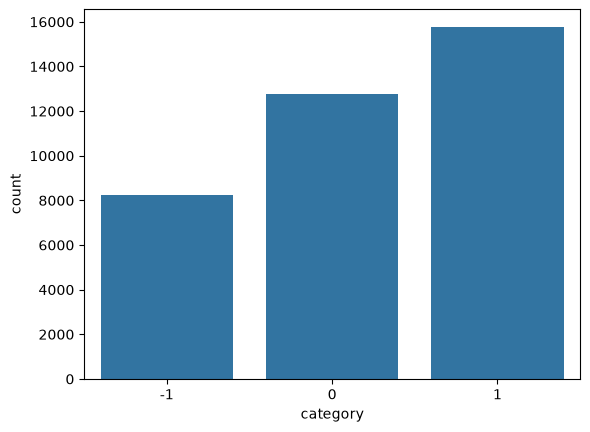

In [24]:
sns.countplot(data=df,x='category')

In [25]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [26]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))

In [27]:
df.sample(5)

,clean_comment,category,word_count
862,because arvind kejriwal reminds robespierre,0,5
27859,iran india suffered from two heinous terrorist...,-1,36
13000,unke ी peela kar poori tarike jisse fir attack...,0,16
13458,wtf bjp,-1,2
23753,tfw when your friend takes psychology course a...,1,39


In [28]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

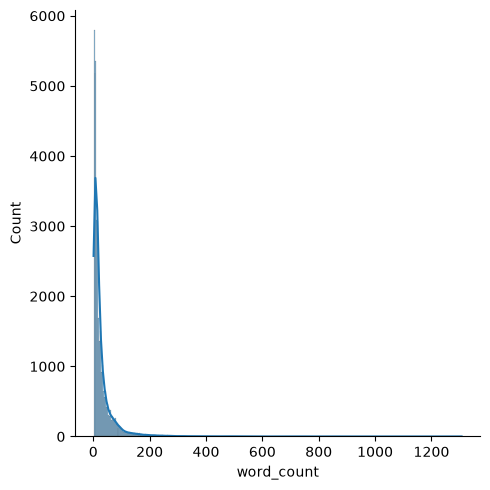

In [29]:
sns.displot(df['word_count'],kde=True)

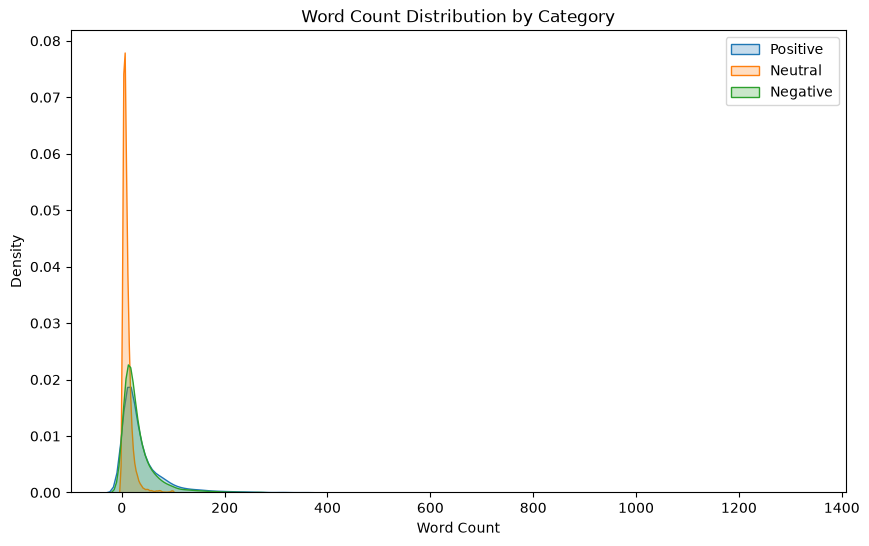

In [30]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category']==1]['word_count'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==0]['word_count'],label='Neutral',fill=True)
sns.kdeplot(df[df['category']==-1]['word_count'],label='Negative',fill=True)

plt.title("Word Count Distribution by Category")
plt.xlabel('Word Count')
plt.ylabel('Density')

plt.legend()
plt.show()

**Positive comments (category 1)**: These tend to have a wider spread in word count, indicating that longer comments are more common in positive sentiments.<br>

**Neutral comments (category 0)**: The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.<br>

**Negative comments (category -1)**: These comments have a distribution somewhat similar to positive comments but with a smaller proportion of longer comments.

<Axes: ylabel='word_count'>

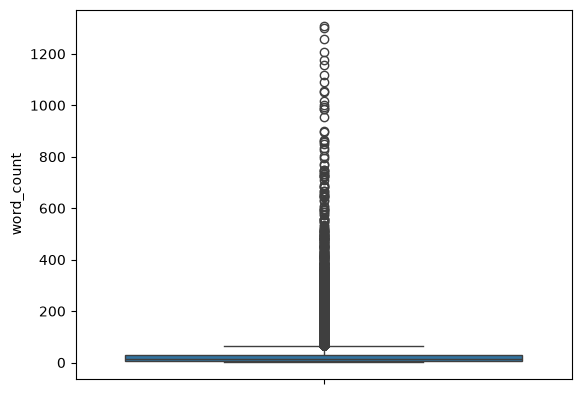

In [31]:
sns.boxplot(df['word_count'])

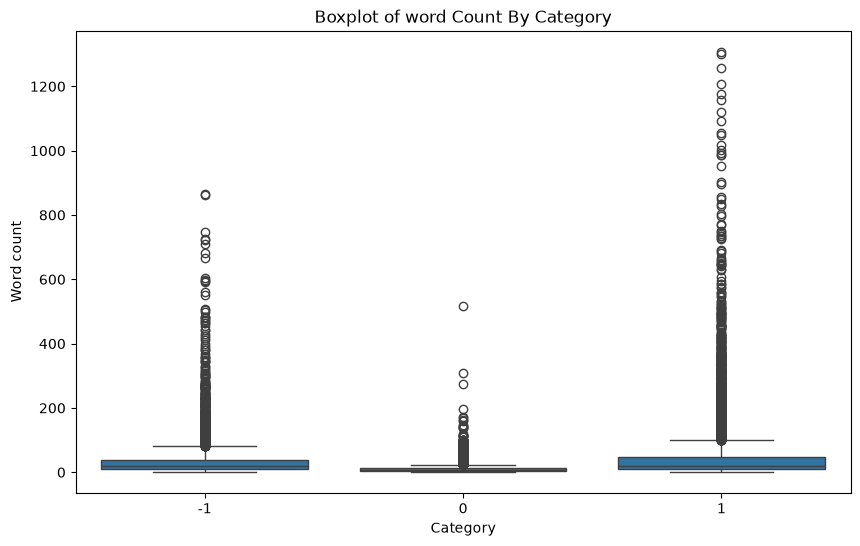

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='word_count')
plt.title("Boxplot of word Count By Category")
plt.xlabel('Category')
plt.ylabel("Word count")
plt.show()

**Positive comments (category 1)**: The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.<br>

**Neutral comments (category 0)**: The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.<br>

**Negative comments (category -1)**: The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers.

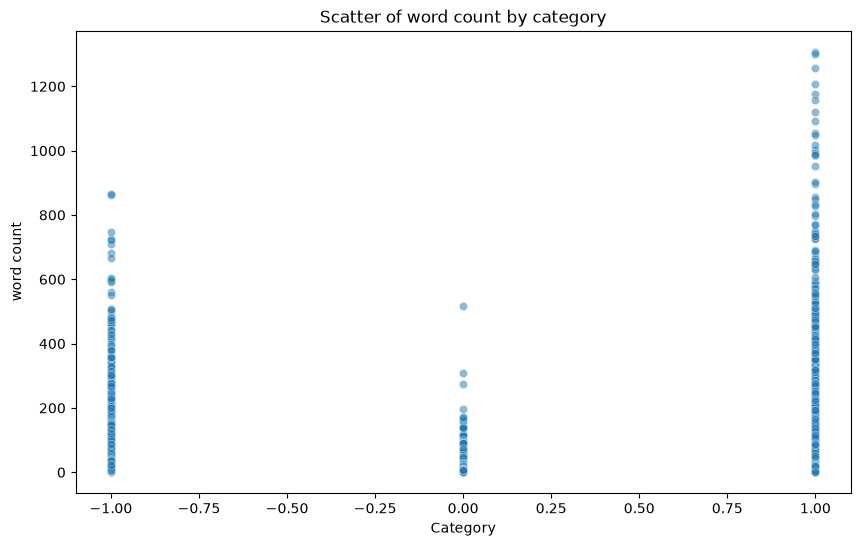

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='category',y='word_count',alpha=0.5)
plt.title("Scatter of word count by category")
plt.xlabel("Category")
plt.ylabel("word count")
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

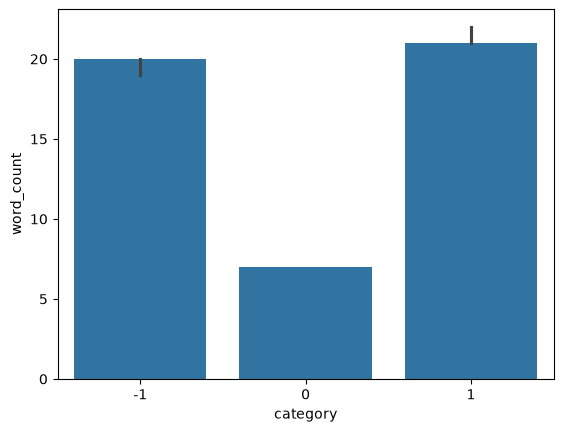

In [34]:
sns.barplot(df,x='category',y='word_count',estimator='median')

In [35]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words=set(stopwords.words('english'))

df['num_stop_words']=df['clean_comment'].apply(lambda x:len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /home/zaheer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
6126,jiya bihar lala,0,3,0
24498,welcome the post truth era where the lies are ...,1,14,6
31754,vreddit\ bot,0,2,0
16866,retweeted this crazy man,-1,4,1
5213,how you know you reached gurgaon while driving...,-1,33,15


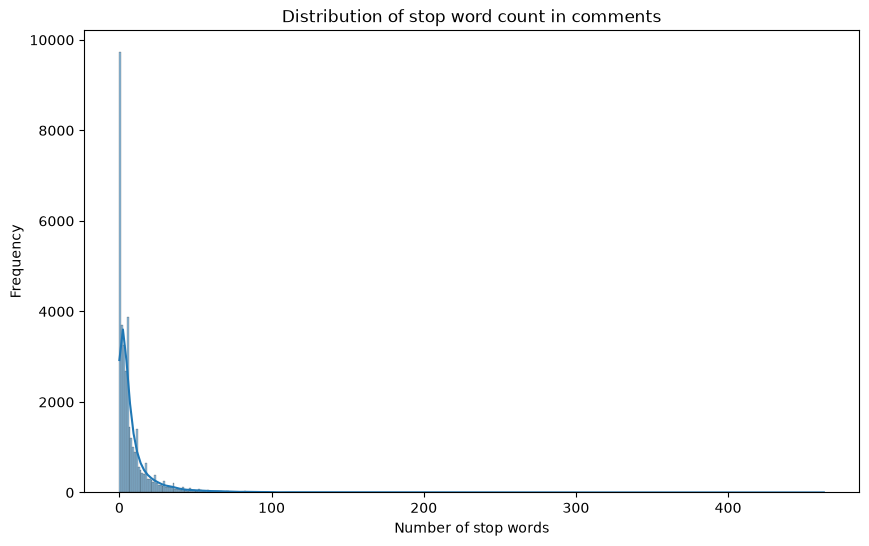

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df['num_stop_words'],kde=True)
plt.title("Distribution of stop word count in comments")
plt.xlabel("Number of stop words")
plt.ylabel("Frequency")
plt.show()

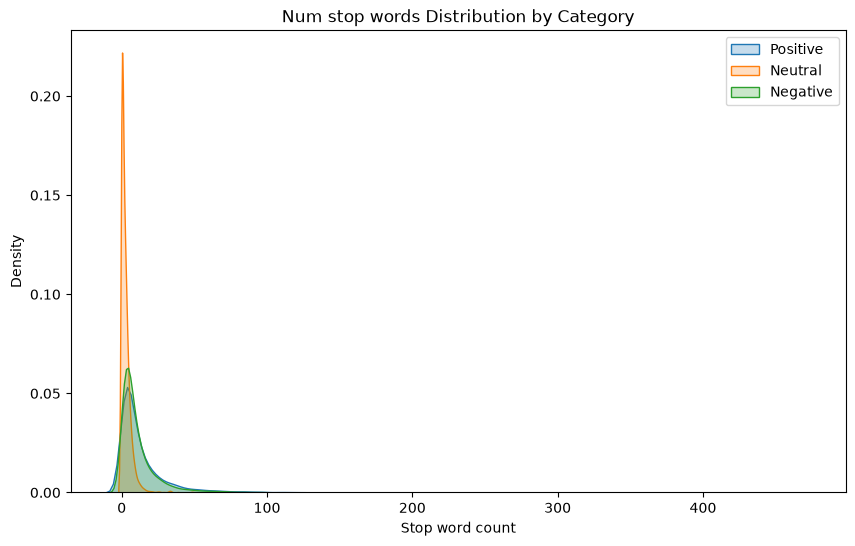

In [38]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category']==1]['num_stop_words'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==0]['num_stop_words'],label='Neutral',fill=True)
sns.kdeplot(df[df['category']==-1]['num_stop_words'],label='Negative',fill=True)

plt.title("Num stop words Distribution by Category")
plt.xlabel('Stop word count')
plt.ylabel('Density')

plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

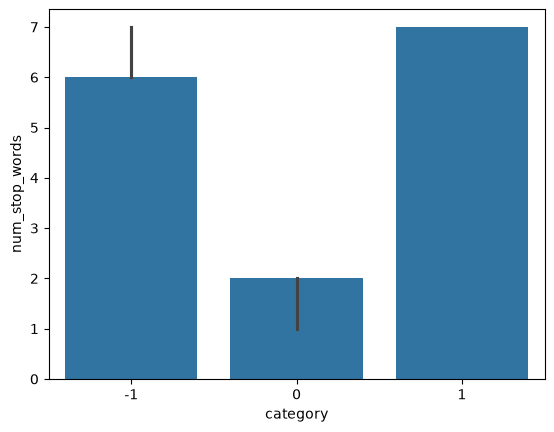

In [39]:
sns.barplot(df,x='category',y='num_stop_words',estimator='median')

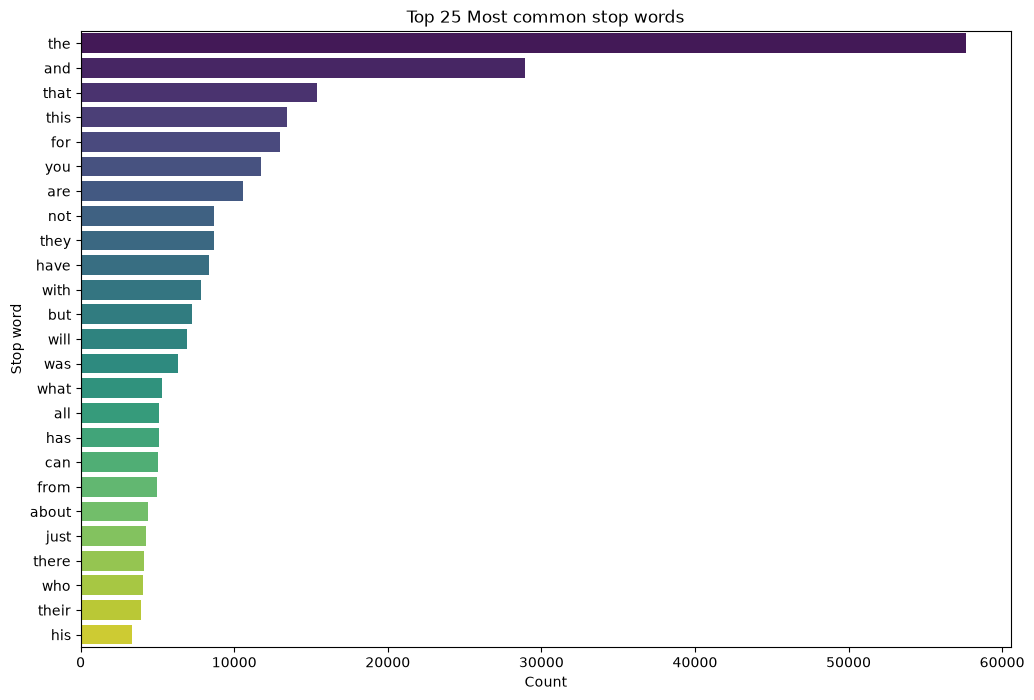

In [40]:
from collections import Counter

all_stop_words=[word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

most_common_stop_words=Counter(all_stop_words).most_common(25)

top_25_df=pd.DataFrame(most_common_stop_words,columns=['stop_word','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='count',y='stop_word',palette='viridis')
plt.title("Top 25 Most common stop words")
plt.xlabel("Count")
plt.ylabel("Stop word")
plt.show()

In [41]:
df['num_chars']=df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [42]:
df['num_chars'].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [43]:
from collections import Counter

all_text=" ".join(df['clean_comment'])

char_frequency=Counter(all_text)

char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency'])

In [44]:
char_frequency_df['character'].values

<ArrowStringArray>
['f', 'a', 'm', 'i', 'l', 'y', ' ', 'o', 'r', 'n',
 ...
 'ֲ', 'ִ', 'ֽ', '׃', 'ജ', 'ണ', 'р', 'ч', 'т', 'ю']
Length: 1378, dtype: str

In [45]:
char_frequency_df.tail(50)

,character,frequency
1328,妖,1
1329,婆,1
1330,段,1
1331,她,1
1332,谁,1
1333,抹,1
1334,掉,1
1335,坛,1
1336,回,1
1337,毫,1


In [46]:
df['num_punctuation_chars']=df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)
df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
20330,whatever happened the anti romeo squad and bet...,0,9,2,54,0
8155,just wondering what are the black patches the ...,-1,10,5,60,0
32309,soldiers are dying the border and these anti n...,0,33,5,107,0
14912,hello there,0,2,1,11,0
9206,this great step modi some highlights 500 and 1...,-1,186,51,1121,0


In [47]:
df['num_punctuation_chars'].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

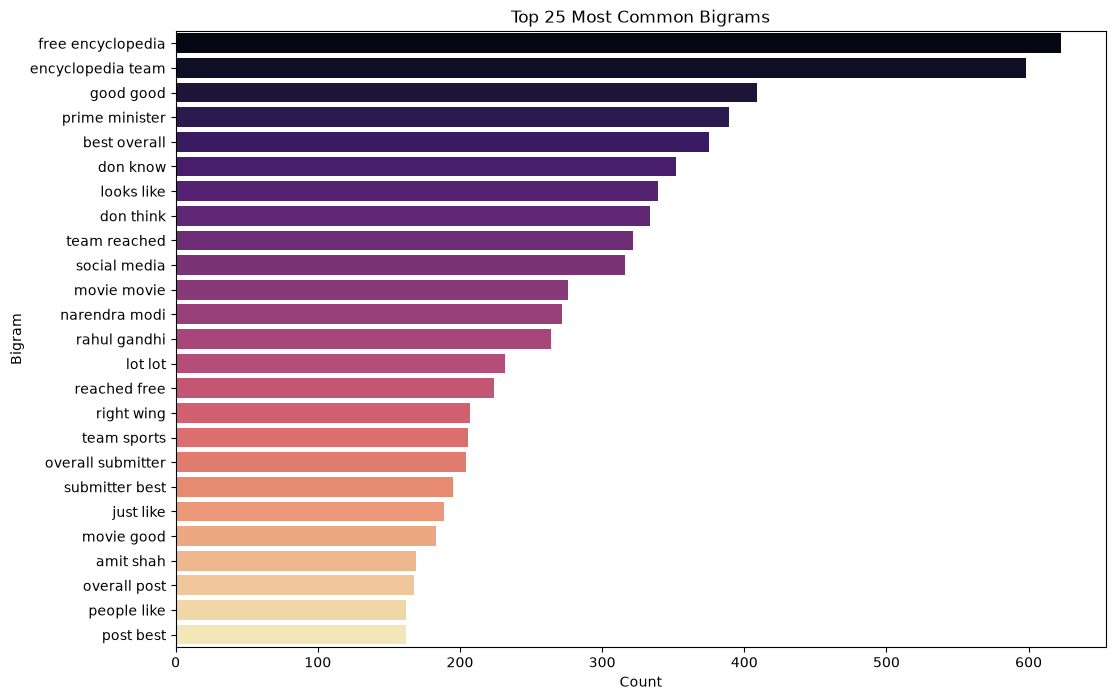

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus,n=None):
    vec=CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
    bag_of_words=vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq,key=lambda x:x[1], reverse=True)
    return words_freq[:n]

top_25_bigrams=get_top_ngram(df['clean_comment'],25)
top_25_bigrams_df=pd.DataFrame(top_25_bigrams,columns=['bigram','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='magma')
plt.title("Top 25 Most Common Bigrams")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.show()

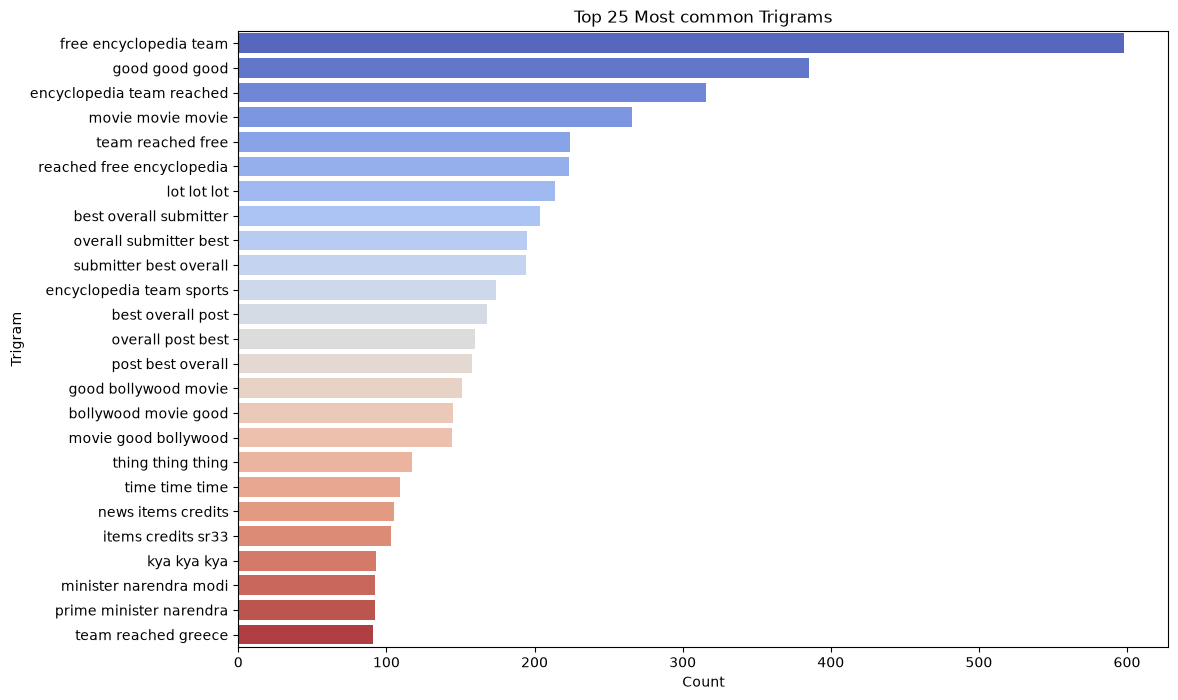

In [49]:
def get_top_trigram(corpus,n=None):
    vec=CountVectorizer(ngram_range=(3,3),stop_words='english').fit(corpus)
    bag_of_words=vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq,key=lambda x:x[1], reverse=True)
    return words_freq[:n]

top_25_trigrams_df=get_top_trigram(df['clean_comment'],25)

top_25_trigrams_df=pd.DataFrame(top_25_trigrams_df,columns=['trigram','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df,x='count',y='trigram',palette='coolwarm')
plt.title("Top 25 Most common Trigrams")
plt.xlabel("Count")
plt.ylabel("Trigram")
plt.show()

In [50]:
import re

df['clean_comment']=df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [51]:
all_text=" ".join(df['clean_comment'])

char_frequency=Counter(all_text)

char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency'])
char_frequency_df

,character,frequency
0,f,78866
1,a,481134
2,m,155561
3,i,401388
4,l,250104
5,y,115420
6,,1091592
7,o,379908
8,r,331425
9,n,388465


In [52]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [53]:
stop_words=set(stopwords.words('english'))-{'not','but','however','no','yet'}

df['clean_comment']=df['clean_comment'].apply(
    lambda x:" ".join([word for word in x.split() if word.lower() not in stop_words])
)

In [54]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [56]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer=WordNetLemmatizer()
df['clean_comment']=df['clean_comment'].apply(
    lambda x:" ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /home/zaheer/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


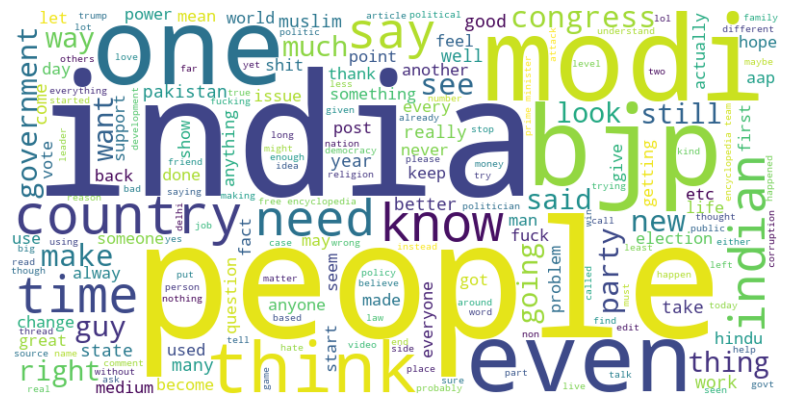

In [58]:
from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud=WordCloud(width=800,height=400,background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show()
    
plot_word_cloud(df['clean_comment'])

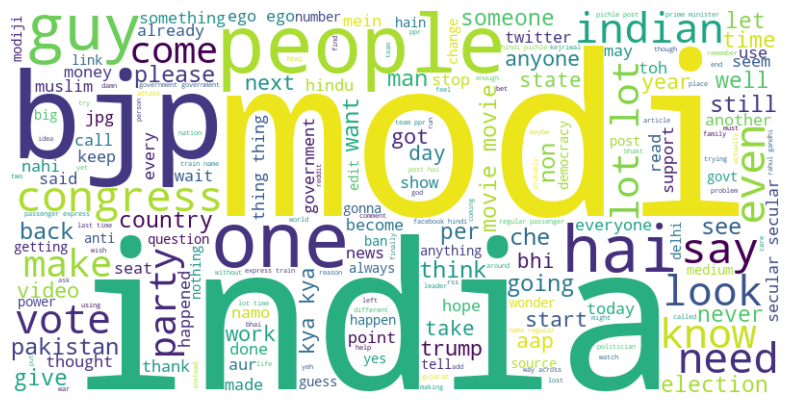

In [59]:
def plot_word_cloud(text):
    wordcloud=WordCloud(width=800,height=400,background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show()
    
plot_word_cloud(df[df['category']==0]['clean_comment'])

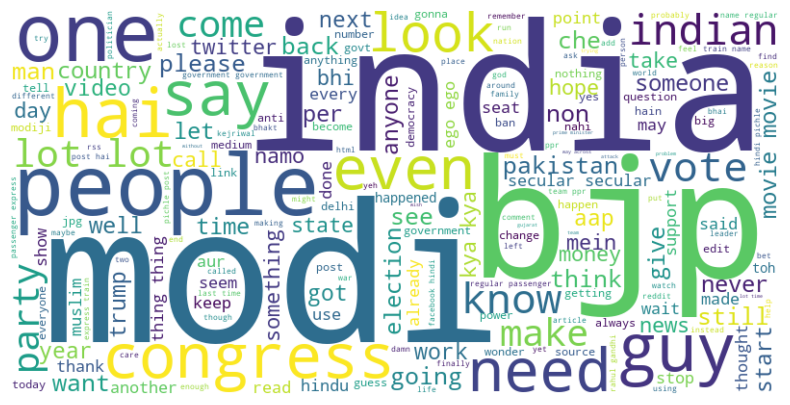

In [60]:
def plot_word_cloud(text):
    wordcloud=WordCloud(width=800,height=400,background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show()
    
plot_word_cloud(df[df['category']==0]['clean_comment'])

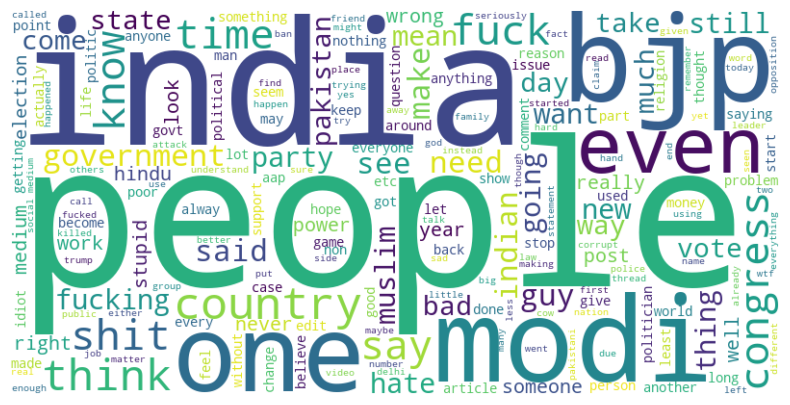

In [61]:
def plot_word_cloud(text):
    wordcloud=WordCloud(width=800,height=400,background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show()
    
plot_word_cloud(df[df['category']==-1]['clean_comment'])

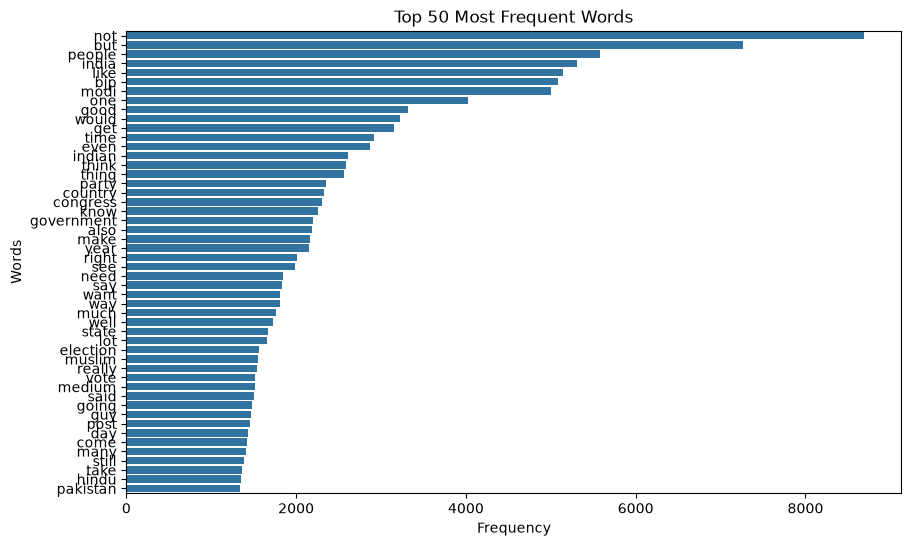

In [63]:
def plot_top_n_words(df,n=20):
    
    words=" ".join(df['clean_comment']).split()
    
    counter=Counter(words)
    most_common_stop_words=counter.most_common(n)
    
    words,counts=zip(*most_common_stop_words)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=list(counts),y=list(words))
    plt.title(f"Top {n} Most Frequent Words")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

plot_top_n_words(df,n=50)

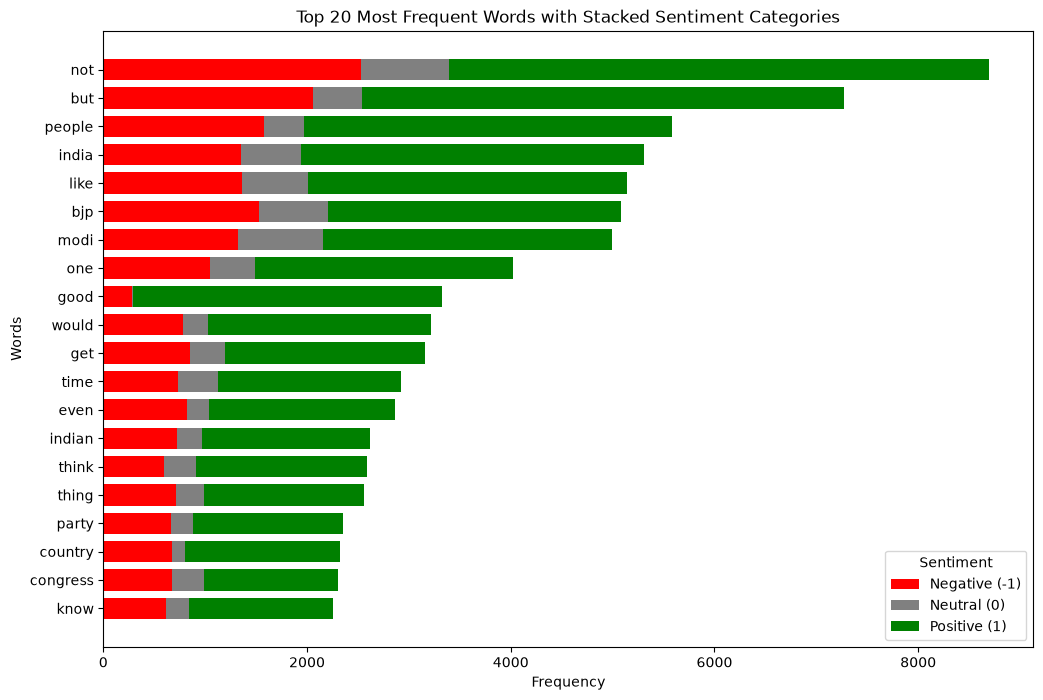

In [ ]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""

    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  

            word_category_counts[word][category] += 1


    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}


    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]


    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]


    plt.figure(figsize=(12, 8))
    bar_width = 0.75


    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  
    plt.show()



plot_top_n_words_by_category(df, n=20)
